## INLAB

## Task-1

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split

# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

X_pima = pima_df[pima_cols[:-1]]
y_pima = pima_df['Outcome']

# Split into 80% train and 20% test partition
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

print("Pima Classification Training Set Shape:", X_train_c.shape)
print("Pima Classification Test Set Shape:", X_test_c.shape)


Pima Classification Training Set Shape: (614, 8)
Pima Classification Test Set Shape: (154, 8)


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Decision Tree Classifier with depth regularization
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train_c, y_train_c)

# Evaluate performance
clf_preds = tree_clf.predict(X_test_c)
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n(24EU02022)")
print("--- Classification Report(24EU02022) ---")
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))


Decision Tree Classifier Test Accuracy: 79.87%
(24EU02022)
--- Classification Report(24EU02022) ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



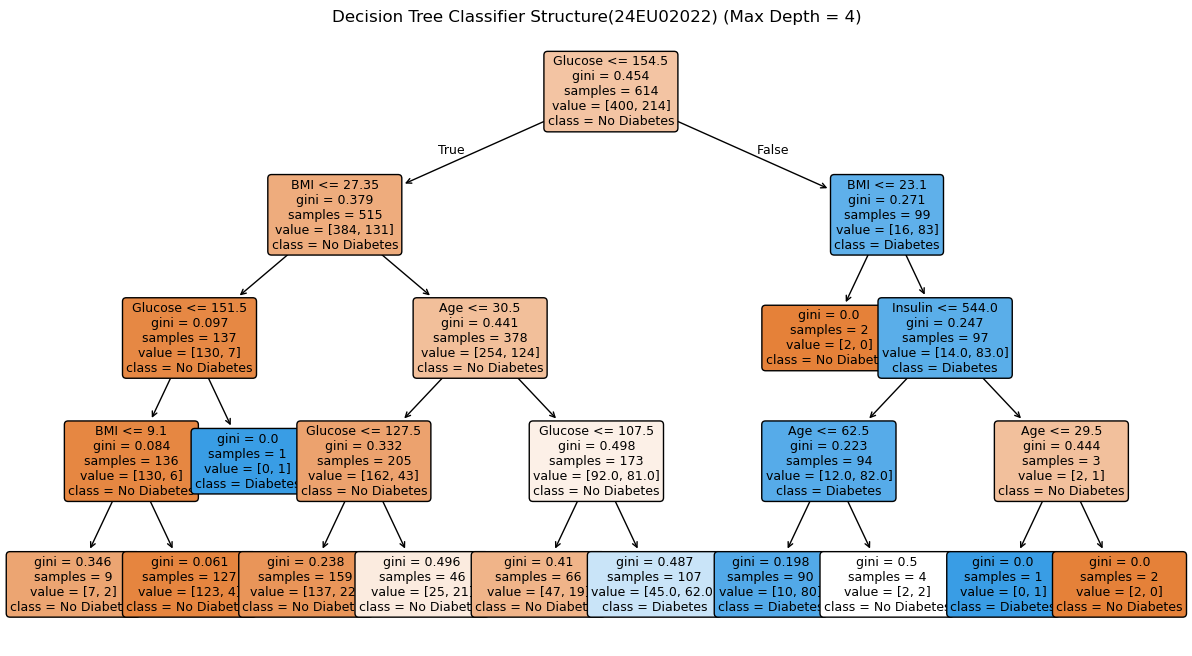

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot tree structure
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure(24EU02022) (Max Depth = 4)")
plt.show()


In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

# Load the Boston Housing dataset from public CSV repository
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(boston_url)

boston_features = [col for col in boston_df.columns if col != 'medv']
X_boston = boston_df[boston_features]
y_boston = boston_df['medv']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

# Standardize features
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_reg.fit(X_train_r_scaled, y_train_r)

print("Decision Tree Regressor trained successfully. Max Depth set to 5.")


Decision Tree Regressor trained successfully. Max Depth set to 5.


Mean Squared Error (MSE): 8.5539
Root Mean Squared Error (RMSE): 2.9247 ($1000s)
R2 Coefficient of Determination: 0.8834



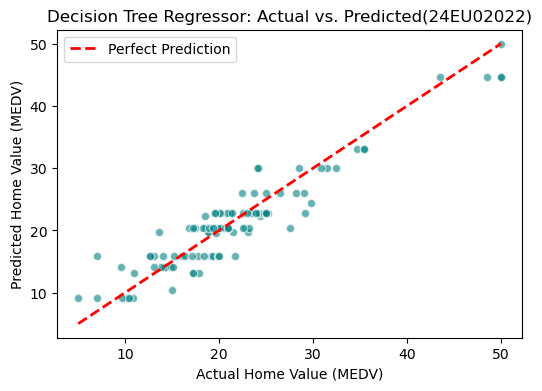

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict and compute metrics
reg_preds = tree_reg.predict(X_test_r_scaled)
mse_val = mean_squared_error(y_test_r, reg_preds)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test_r, reg_preds)

print(f"Mean Squared Error (MSE): {mse_val:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

# Plot Actual vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted(24EU02022)")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()


## TASK-2

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test validation partitions
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Initialize and train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)

# Evaluate accuracy
bagging_preds = bagging_model.predict(X_test_s)
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")


Bagging Classifier Test Accuracy: 80.95%


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_s, y_train_s)

# Evaluate accuracy
rf_preds = rf_model.predict(X_test_s)
rf_accuracy = accuracy_score(y_test_s, rf_preds)

print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


In [10]:

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Define base estimators
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

# Initialize and train soft Voting Classifier
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_model.fit(X_train_s, y_train_s)

# Evaluate accuracy
voting_preds = voting_model.predict(X_test_s)
voting_accuracy = accuracy_score(y_test_s, voting_preds)

print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


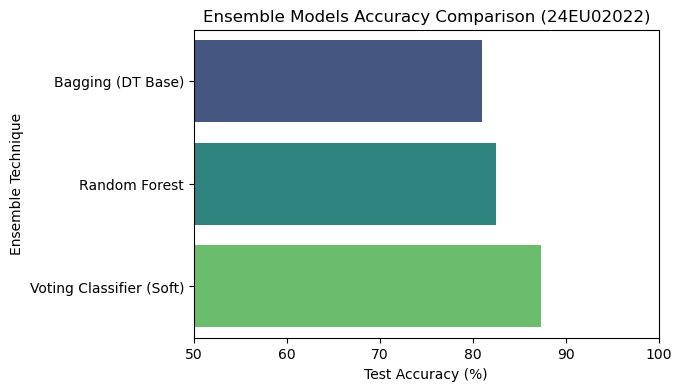

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compile results
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison (24EU02022)")
plt.show()

## TASK-3

In [13]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Initialize and train AdaBoost Classifier (with default Decision Tree stumps)
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train_s, y_train_s)

# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)
ada_accuracy = accuracy_score(y_test_s, ada_preds)

print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


In [14]:

from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_s, y_train_s)

# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)
gb_accuracy = accuracy_score(y_test_s, gb_preds)

print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


In [15]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train_s, y_train_s)

# Extract optimized model and predict
best_gb = grid_gb.best_estimator_
tuned_gb_preds = best_gb.predict(X_test_s)
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Tuned Gradient Boosting Test Accuracy: 79.37%


In [16]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

print("--- Master Performance Table: Tasks 2 & 3 ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 ---
        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


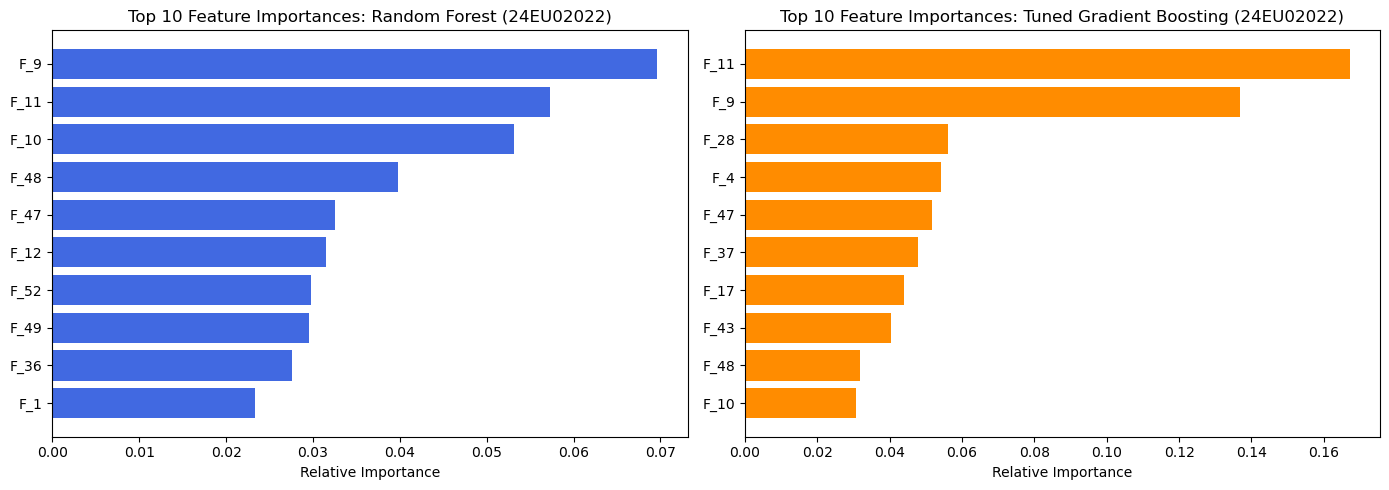

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_

# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]

# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]

# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest (24EU02022)")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting (24EU02022)")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()


## POST LAB

In [19]:
# ==========================================
# POST LAB TASK
# TITANIC DATASET CLASSIFICATION
# ==========================================

# Import Libraries
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Titanic Dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
print(df.head())

# Select Required Features
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# Handle Missing Values
imputer = SimpleImputer(strategy='most_frequent')
df[['age', 'embarked']] = imputer.fit_transform(df[['age', 'embarked']])

# Encode Categorical Columns
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['embarked'] = encoder.fit_transform(df['embarked'])

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train the Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Accuracy Score:
0.7653631284916201

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72       

In [20]:
import pandas as pd

# Sample California Housing Dataset
data = {
    "MedInc": [8.3252, 8.3014, 7.2574, 5.6431, 3.8462,
               4.0368, 3.6591, 3.1200, 2.0804, 3.6912,
               3.2031, 3.2705, 3.0750, 2.6736, 1.9167,
               2.1250, 2.7750, 2.1202, 1.9911, 2.6033],

    "HouseAge": [41, 21, 52, 52, 52,
                 52, 52, 42, 52, 52,
                 42, 52, 52, 52, 52,
                 50, 52, 40, 34, 36],

    "AveRooms": [6.9841, 6.2381, 8.2881, 5.8174, 6.2819,
                 4.7617, 4.9319, 4.7975, 4.2941, 4.9706,
                 5.0806, 4.8345, 4.8269, 4.1200, 4.0541,
                 4.3214, 5.1120, 4.6789, 4.5023, 5.2101],

    "AveBedrms": [1.0238, 0.9719, 1.0734, 1.0731, 1.0811,
                  1.1036, 1.1036, 1.0248, 1.1176, 0.9902,
                  1.0200, 1.0800, 1.0650, 1.0900, 1.1200,
                  1.0300, 1.0400, 1.0500, 1.0600, 1.0100],

    "Population": [322, 2401, 496, 558, 565,
                   413, 1094, 1157, 1206, 1551,
                   980, 1100, 1400, 870, 920,
                   1010, 1230, 1125, 980, 1340],

    "AveOccup": [2.5556, 2.1098, 2.8023, 2.5479, 2.1815,
                 2.1399, 2.1284, 1.7883, 2.0269, 2.1723,
                 2.3000, 2.1200, 2.4500, 2.0100, 2.2200,
                 2.1800, 2.3600, 2.1400, 2.2700, 2.3100],

    "Latitude": [37.88, 37.86, 37.85, 37.85, 37.85,
                 37.85, 37.84, 37.84, 37.84, 37.84,
                 37.83, 37.83, 37.82, 37.82, 37.81,
                 37.81, 37.80, 37.80, 37.79, 37.79],

    "Longitude": [-122.23, -122.22, -122.24, -122.25, -122.25,
                  -122.25, -122.26, -122.26, -122.27, -122.27,
                  -122.28, -122.28, -122.29, -122.30, -122.30,
                  -122.31, -122.32, -122.33, -122.34, -122.35],

    "MedHouseVal": [4.526, 3.585, 3.521, 3.413, 3.422,
                    2.697, 2.992, 2.414, 2.267, 2.611,
                    2.450, 2.300, 2.100, 1.980, 1.850,
                    1.920, 2.050, 2.120, 1.990, 2.250]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save as CSV
df.to_csv("california_housing_sample.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


First 5 Rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Regression Performance
-----------------------
Mean Absolute Error (MAE): 0.45467918846899225
Mean Squared Error (MSE): 0.495235205629094
R2 Score: 0.622075845135081

Actual vs Predicted (First 10 Rows):
    Actual  Predicted
0  0.47700    0.41400
1  0.45800    1.20300
2  5.00001    5.00001
3  2.18600    2.17000
4  2.78000    2.25700
5  1.58700    1.78700
6  1.98200    2.21700
7  1.57500    1.74000
8  3.40000    2.77200
9  

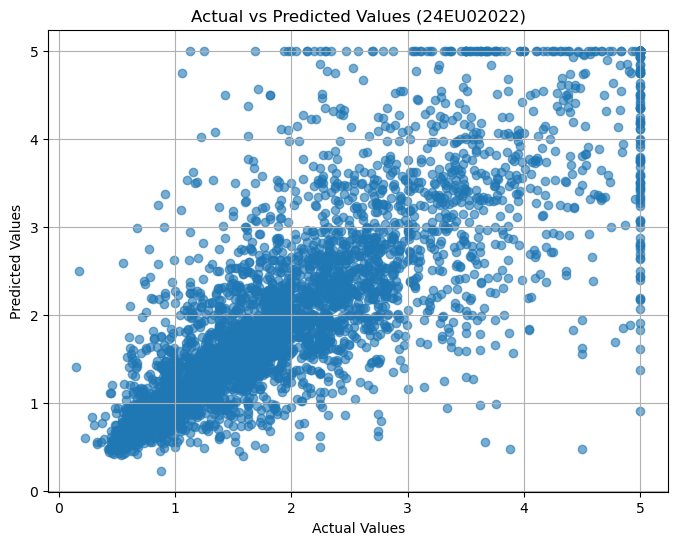

In [22]:
# ==========================================
# POST LAB TASK
# CALIFORNIA HOUSING DATASET REGRESSION
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load California Housing Dataset
housing = fetch_california_housing()

# Create DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(X.head())

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)

# Train the Model
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)

# Evaluation Metrics
print("\nRegression Performance")
print("-----------------------")
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted (First 10 Rows):")
print(comparison.head(10))

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (24EU02022)")
plt.grid(True)
plt.show()